In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def calculate_obv(data):
    """Calculate On-Balance Volume"""
    obv = pd.Series(index=data.index)
    obv.iloc[0] = data['Volume'].iloc[0]
    
    for i in range(1, len(data)):
        if data['Close'].iloc[i] > data['Close'].iloc[i-1]:
            obv.iloc[i] = obv.iloc[i-1] + data['Volume'].iloc[i]
        elif data['Close'].iloc[i] < data['Close'].iloc[i-1]:
            obv.iloc[i] = obv.iloc[i-1] - data['Volume'].iloc[i]
        else:
            obv.iloc[i] = obv.iloc[i-1]
    
    return obv

def generate_signals(data, obv, window=20):
    """Generate buy/sell signals based on OBV and its moving average"""
    # Calculate OBV moving average
    obv_ma = obv.rolling(window=window).mean()
    
    # Initialize signals DataFrame
    signals = pd.DataFrame(index=data.index)
    signals['Price'] = data['Close']
    signals['OBV'] = obv
    signals['OBV_MA'] = obv_ma
    
    # Generate signals
    signals['Signal'] = 0
    signals.loc[obv > obv_ma, 'Signal'] = 1  # Buy signal
    signals.loc[obv < obv_ma, 'Signal'] = -1  # Sell signal
    
    # Get signal changes for plotting
    signals['Signal_Change'] = signals['Signal'].diff()
    
    return signals

def plot_obv_signals(data, signals):
    """Plot price, OBV, and signals"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), height_ratios=[2, 1])
    
    # Plot price
    ax1.plot(data.index, data['Close'], label='SPY Price', color='blue', alpha=0.7)
    
    # Plot buy signals
    buy_signals = signals[signals['Signal_Change'] == 1]
    sell_signals = signals[signals['Signal_Change'] == -1]
    
    ax1.scatter(buy_signals.index, buy_signals['Price'], 
                marker='^', color='green', s=100, label='Buy Signal')
    ax1.scatter(sell_signals.index, sell_signals['Price'], 
                marker='v', color='red', s=100, label='Sell Signal')
    
    ax1.set_title('SPY Price with OBV Signals')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Plot OBV
    ax2.plot(signals.index, signals['OBV'], label='OBV', color='blue')
    ax2.plot(signals.index, signals['OBV_MA'], label='OBV MA', color='orange')
    ax2.set_title('On-Balance Volume (OBV)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('OBV')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()


Date
2022-12-21 00:00:00-05:00     78167400
2022-12-22 00:00:00-05:00    100120900
2022-12-23 00:00:00-05:00     59857300
2022-12-27 00:00:00-05:00     51638200
2022-12-28 00:00:00-05:00     70911500
                               ...    
2024-12-16 00:00:00-05:00     43695200
2024-12-17 00:00:00-05:00     55773500
2024-12-18 00:00:00-05:00    108248700
2024-12-19 00:00:00-05:00     85919500
2024-12-20 00:00:00-05:00    125535900
Name: Volume, Length: 503, dtype: int64


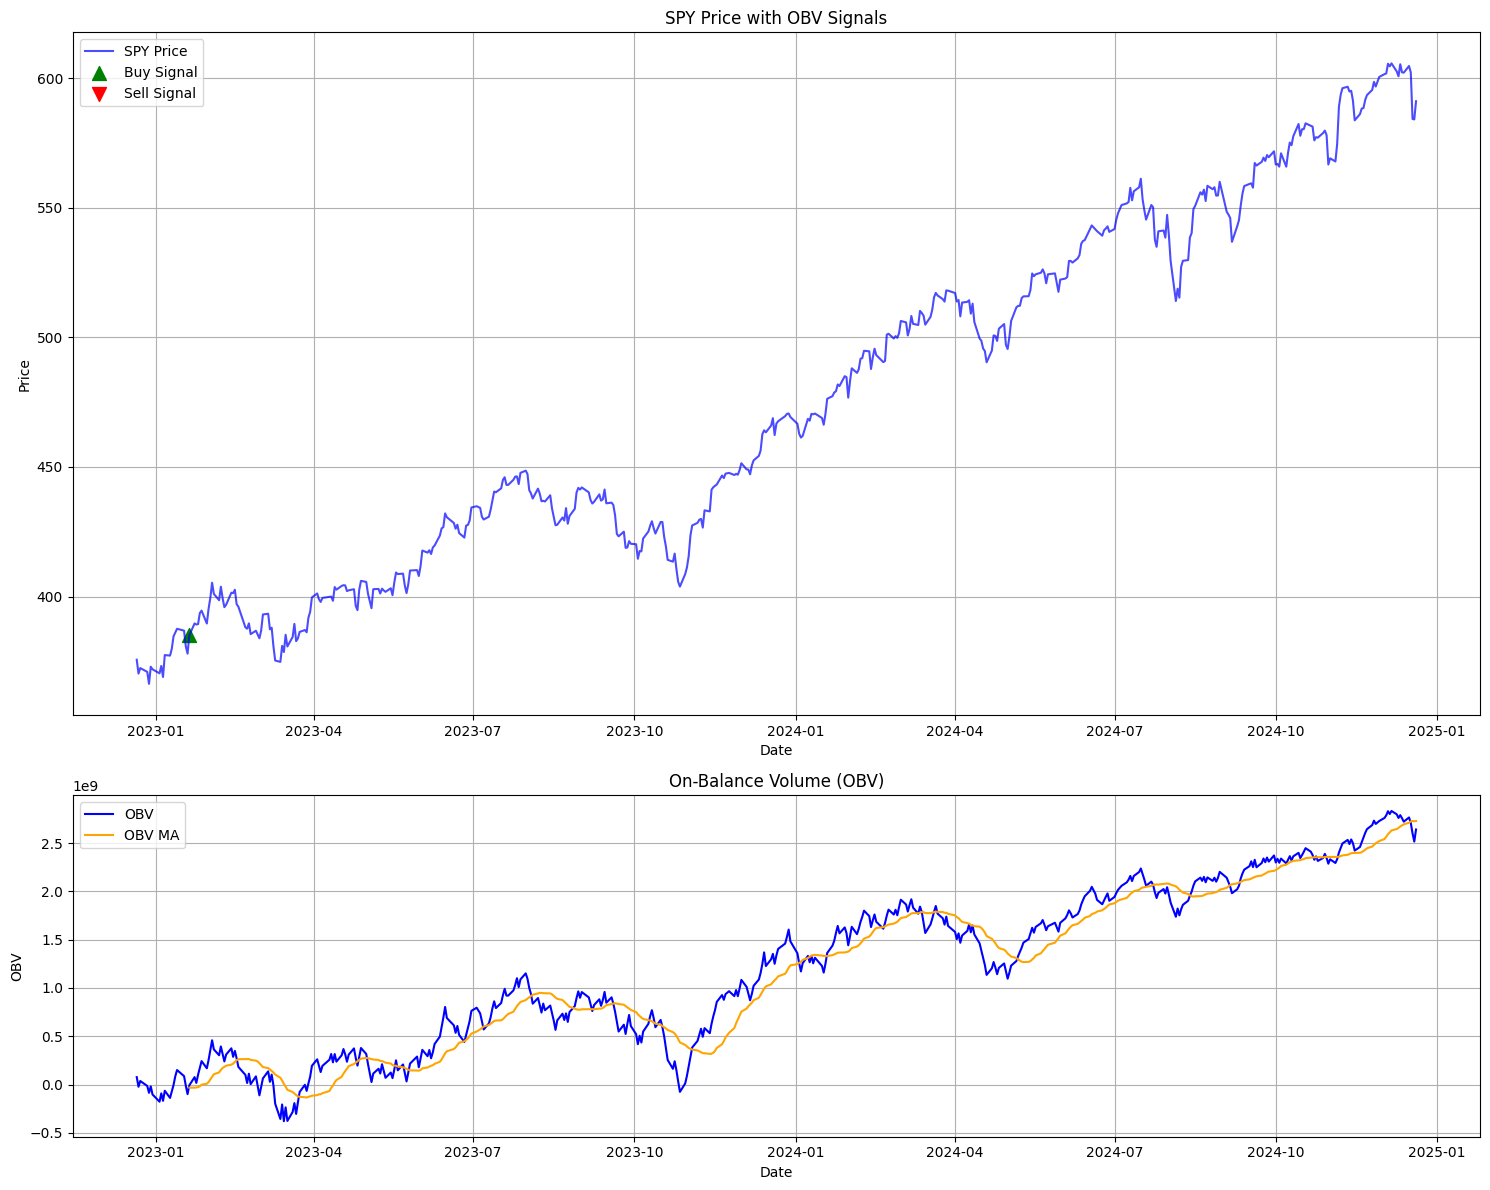


Recent Signals:
2024-10-25: SELL at $577.10
2024-10-29: SELL at $579.82
2024-10-30: SELL at $578.06
2024-11-06: SELL at $589.06
2024-12-17: SELL at $602.26


In [9]:
# Download SPY data
ticker_value = 'SPY'
ticker = yf.Ticker(ticker_value)
spy = ticker.history(period="2y")

# Calculate OBV
obv = calculate_obv(spy)

# Generate signals
signals = generate_signals(spy, obv)

# Plot results
plot_obv_signals(spy, signals)

# Print last few signals with prices
recent_signals = signals[signals['Signal_Change'] != 0].tail()
print("\nRecent Signals:")
for date, row in recent_signals.iterrows():
    signal_type = "BUY" if row['Signal_Change'] == 1 else "SELL"
    print(f"{date.date()}: {signal_type} at ${row['Price']:.2f}")